11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Loaded!


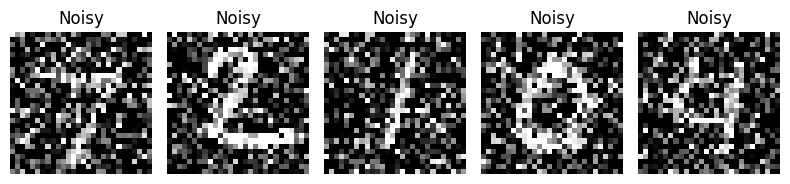


Model Built Successfully!
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0522 - val_loss: 0.0327
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0280 - val_loss: 0.0240
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0224 - val_loss: 0.0206
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0199 - val_loss: 0.0187
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0185 - val_loss: 0.0179
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0177 - val_loss: 0.0173
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0172 - val_loss: 0.0170
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0169 - val_loss: 0.0168
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0166 - val_loss: 0.0165
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0164 - val_loss: 0.0164

Model Training Completed!
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


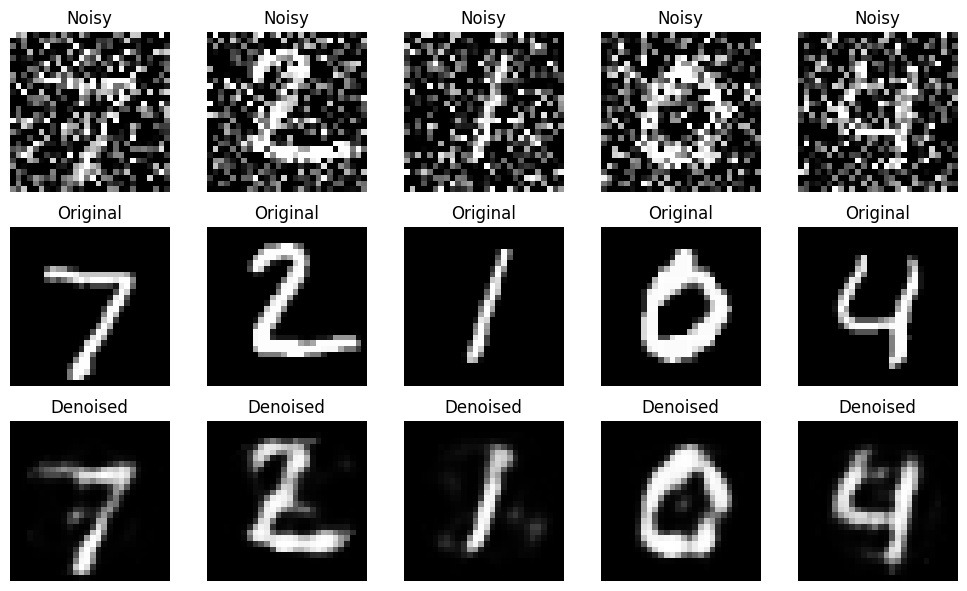

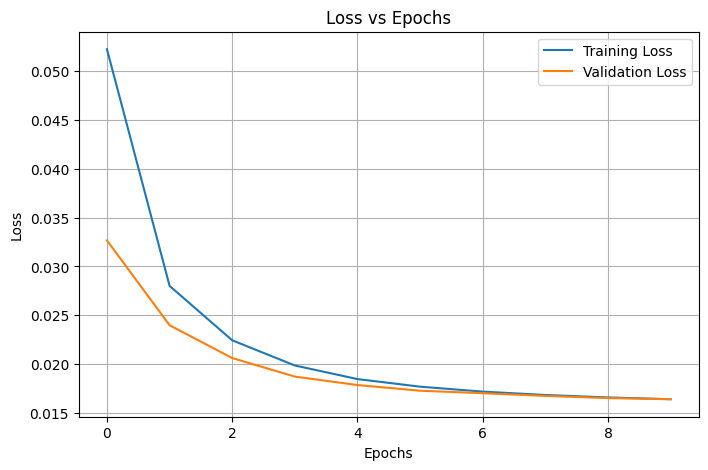

In [1]:
# ============================================================
# EXP 10: AUTOENCODER FOR IMAGE DENOISING
# ============================================================

# STEP 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

# STEP 2: Load Dataset
(X_train, _), (X_test, _) = mnist.load_data()

print("Dataset Loaded!")

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# STEP 3: Add Noise
noise_factor = 0.5

X_train_noisy = X_train + noise_factor * np.random.normal(size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(size=X_test.shape)

# Clip values
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

# Show noisy images
plt.figure(figsize=(8,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
plt.tight_layout()
plt.show()


# STEP 4: Build Autoencoder
input_img = Input(shape=(28,28))

# Encoder
x = Flatten()(input_img)
encoded = Dense(64, activation='relu')(x)

# Decoder
decoded = Dense(28*28, activation='sigmoid')(encoded)
decoded = Reshape((28,28))(decoded)

# Model
autoencoder = Model(input_img, decoded)

# Compile
autoencoder.compile(optimizer='adam', loss='mse')

print("\nModel Built Successfully!")


# STEP 5: Train Model
history = autoencoder.fit(
    X_train_noisy, X_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test_noisy, X_test)
)

print("\nModel Training Completed!")


# STEP 6: Reconstruction
decoded_imgs = autoencoder.predict(X_test_noisy)

# STEP 7: Visualization (Clean vs Noisy vs Reconstructed)
plt.figure(figsize=(10,6))

for i in range(5):
    # Noisy
    plt.subplot(3,5,i+1)
    plt.imshow(X_test_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Clean
    plt.subplot(3,5,i+6)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(3,5,i+11)
    plt.imshow(decoded_imgs[i], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()


# STEP 8: Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()